# Day 09. Exercise 00
# Regularization

## 0. Imports

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.metrics import accuracy_score, root_mean_squared_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import gdown

In [10]:
url='https://drive.google.com/uc?id=1uBiIFvD2iCiAkUNHmJknlVPHpUvBxt6N&export=download'

output='dayofweek.csv'
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1uBiIFvD2iCiAkUNHmJknlVPHpUvBxt6N&export=download
To: /home/mirshod/Desktop/DSB11_ML_Advanced.ID_886524-1/src/ex00/dayofweek.csv
100%|██████████| 393k/393k [00:00<00:00, 863kB/s]


'dayofweek.csv'

## 1. Preprocessing

1. Read the file `dayofweek.csv` that you used in the previous day to a dataframe.
2. Using `train_test_split` with parameters `test_size=0.2`, `random_state=21` get `X_train`, `y_train`, `X_test`, `y_test`. Use the additional parameter `stratify`.

In [11]:
df=pd.read_csv('dayofweek.csv')
df.head()

,Unnamed: 0,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,...,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1,target
0,0,-0.788667,-2.562352,0.321862,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,True
1,1,-0.756764,-2.562352,0.321862,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,True
2,2,-0.724861,-2.562352,0.321862,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,True
3,3,-0.692958,-2.562352,0.321862,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,True
4,4,-0.661055,-2.562352,0.321862,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,True


In [12]:
dayofweek=df['dayofweek']

In [13]:
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)
X=df.drop(['target', 'dayofweek', 'labname_project1'], axis=1)
y=df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21, stratify=y)

## 2. Logreg regularization

### a. Default regularization

1. Train a baseline model with the only parameters `random_state=21`, `fit_intercept=False`.
2. Use stratified K-fold cross-validation with `10` splits to evaluate the accuracy of the model


The result of the code where you trained and evaluated the baseline model should be exactly like this (use `%%time` to get the info about how long it took to run the cell):

```
train -  0.62902   |   valid -  0.59259
train -  0.64633   |   valid -  0.62963
train -  0.63479   |   valid -  0.56296
train -  0.65622   |   valid -  0.61481
train -  0.63397   |   valid -  0.57778
train -  0.64056   |   valid -  0.59259
train -  0.64138   |   valid -  0.65926
train -  0.65952   |   valid -  0.56296
train -  0.64333   |   valid -  0.59701
train -  0.63674   |   valid -  0.62687
Average accuracy on crossval is 0.60165
Std is 0.02943
```

In [14]:
def crossval(n_splits, X, y, model):
  kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=21)
  accuracy_scores = []
  for train_index, test_index in kf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy_valid = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy_valid)
    y_train_pred = model.predict(X_train)
    accuracy_train = accuracy_score(y_train, y_train_pred)
    print(f'train - {accuracy_train:.5f}   |   valid - {accuracy_valid:.5f}')
  print(f'Average accuracy on crossval is {np.mean(accuracy_scores):.5f}')
  print(f'Std is {np.std(accuracy_scores):.5f}')

In [15]:
%%timeit
logreg=LogisticRegression(random_state=21, fit_intercept=False)
crossval( 10, X, y,logreg)

train - 0.82202   |   valid - 0.85799
train - 0.83454   |   valid - 0.79290
train - 0.82334   |   valid - 0.78107
train - 0.82334   |   valid - 0.83432
train - 0.82531   |   valid - 0.82249
train - 0.82795   |   valid - 0.84615
train - 0.83070   |   valid - 0.84524
train - 0.82213   |   valid - 0.82143
train - 0.82609   |   valid - 0.74405
train - 0.82213   |   valid - 0.83929
Average accuracy on crossval is 0.81849
Std is 0.03368
train - 0.82202   |   valid - 0.85799
train - 0.83454   |   valid - 0.79290
train - 0.82334   |   valid - 0.78107
train - 0.82334   |   valid - 0.83432
train - 0.82531   |   valid - 0.82249
train - 0.82795   |   valid - 0.84615
train - 0.83070   |   valid - 0.84524
train - 0.82213   |   valid - 0.82143
train - 0.82609   |   valid - 0.74405
train - 0.82213   |   valid - 0.83929
Average accuracy on crossval is 0.81849
Std is 0.03368
train - 0.82202   |   valid - 0.85799
train - 0.83454   |   valid - 0.79290
train - 0.82334   |   valid - 0.78107
train - 0.82334 

### b. Optimizing regularization parameters

1. In the cells below try different values of penalty: `none`, `l1`, `l2` – you can change the values of solver too.

In [16]:
model_l1=LogisticRegression(penalty='l1', solver='liblinear', random_state=21, fit_intercept=False)
crossval( 10, X, y,model_l1)

train - 0.82663   |   valid - 0.85799
train - 0.83586   |   valid - 0.78698
train - 0.82465   |   valid - 0.76923
train - 0.82597   |   valid - 0.82840
train - 0.83059   |   valid - 0.82249
train - 0.82927   |   valid - 0.83432
train - 0.83531   |   valid - 0.83333
train - 0.82806   |   valid - 0.82738
train - 0.83202   |   valid - 0.75595
train - 0.82609   |   valid - 0.85119
Average accuracy on crossval is 0.81673
Std is 0.03255


In [17]:
model_l2=LogisticRegression(penalty='l2', solver='liblinear', random_state=21, fit_intercept=False)
crossval( 10, X, y,model_l2)

train - 0.82202   |   valid - 0.85799
train - 0.83388   |   valid - 0.79290
train - 0.82334   |   valid - 0.78107
train - 0.82334   |   valid - 0.83432
train - 0.82465   |   valid - 0.82249
train - 0.82861   |   valid - 0.84615
train - 0.83070   |   valid - 0.84524
train - 0.82213   |   valid - 0.82143
train - 0.82609   |   valid - 0.74405
train - 0.82082   |   valid - 0.83929
Average accuracy on crossval is 0.81849
Std is 0.03368


In [18]:
model=LogisticRegression(solver='liblinear', random_state=21, fit_intercept=False)
crossval( 10, X, y,model)

train - 0.82202   |   valid - 0.85799
train - 0.83388   |   valid - 0.79290
train - 0.82334   |   valid - 0.78107
train - 0.82334   |   valid - 0.83432
train - 0.82465   |   valid - 0.82249
train - 0.82861   |   valid - 0.84615
train - 0.83070   |   valid - 0.84524
train - 0.82213   |   valid - 0.82143
train - 0.82609   |   valid - 0.74405
train - 0.82082   |   valid - 0.83929
Average accuracy on crossval is 0.81849
Std is 0.03368


## 3. SVM regularization

### a. Default regularization

1. Train a baseline model with the only parameters `probability=True`, `kernel='linear'`, `random_state=21`.
2. Use stratified K-fold cross-validation with `10` splits to evaluate the accuracy of the model.
3. The format of the result of the code where you trained and evaluated the baseline model should be similar to what you have got for the logreg.

In [19]:
svm=SVC(probability=True, kernel='linear', random_state=21)
crossval( 10, X, y,svm)

train - 0.82465   |   valid - 0.85799
train - 0.83322   |   valid - 0.78107
train - 0.82729   |   valid - 0.83432
train - 0.82993   |   valid - 0.83432
train - 0.82795   |   valid - 0.82840
train - 0.82993   |   valid - 0.82840
train - 0.82806   |   valid - 0.82143
train - 0.82938   |   valid - 0.81548
train - 0.83465   |   valid - 0.76786
train - 0.82740   |   valid - 0.86310
Average accuracy on crossval is 0.82324
Std is 0.02829


### b. Optimizing regularization parameters

1. In the cells below try different values of the parameter `C`.

In [20]:
svm_lin=SVC(probability=True, kernel='linear', random_state=21, C=0.1)
crossval( 10, X, y,svm_lin)

train - 0.81806   |   valid - 0.85207
train - 0.82597   |   valid - 0.78107
train - 0.82268   |   valid - 0.81065
train - 0.81872   |   valid - 0.84615
train - 0.82070   |   valid - 0.82840
train - 0.81872   |   valid - 0.84615
train - 0.82213   |   valid - 0.81548
train - 0.82411   |   valid - 0.79762
train - 0.82872   |   valid - 0.75595
train - 0.81489   |   valid - 0.88095
Average accuracy on crossval is 0.82145
Std is 0.03520


In [21]:
svm_lin=SVC(probability=True, kernel='linear', random_state=21, C=0.3)
crossval( 10, X, y,svm_lin)

train - 0.81806   |   valid - 0.85207
train - 0.82597   |   valid - 0.78107
train - 0.82268   |   valid - 0.81065
train - 0.81872   |   valid - 0.84615
train - 0.82070   |   valid - 0.82840
train - 0.82399   |   valid - 0.84024
train - 0.82213   |   valid - 0.81548
train - 0.82411   |   valid - 0.79762
train - 0.82872   |   valid - 0.75595
train - 0.82213   |   valid - 0.87500
Average accuracy on crossval is 0.82026
Std is 0.03383


In [22]:
svm_lin=SVC(probability=True, kernel='linear', random_state=21, C=3.0)
crossval( 10, X, y,svm_lin)

train - 0.82531   |   valid - 0.85799
train - 0.83388   |   valid - 0.78107
train - 0.82795   |   valid - 0.83432
train - 0.83059   |   valid - 0.83432
train - 0.82861   |   valid - 0.82840
train - 0.83059   |   valid - 0.82840
train - 0.82806   |   valid - 0.82143
train - 0.83004   |   valid - 0.81548
train - 0.83531   |   valid - 0.76786
train - 0.82806   |   valid - 0.86310
Average accuracy on crossval is 0.82324
Std is 0.02829


In [23]:
svm_lin=SVC(probability=True, kernel='linear', random_state=21, C=10.0)
crossval( 10, X, y,svm_lin)

train - 0.82531   |   valid - 0.85799
train - 0.83388   |   valid - 0.78107
train - 0.82795   |   valid - 0.83432
train - 0.83059   |   valid - 0.83432
train - 0.82861   |   valid - 0.82840
train - 0.83059   |   valid - 0.82840
train - 0.82806   |   valid - 0.82143
train - 0.83004   |   valid - 0.81548
train - 0.83531   |   valid - 0.76786
train - 0.82806   |   valid - 0.86310
Average accuracy on crossval is 0.82324
Std is 0.02829


## 4. Tree

### a. Default regularization

1. Train a baseline model with the only parameter `max_depth=10` and `random_state=21`.
2. Use stratified K-fold cross-validation with `10` splits to evaluate the accuracy of the model.
3. The format of the result of the code where you trained and evaluated the baseline model should be similar to what you have got for the logreg.

In [24]:
decision_tree=DecisionTreeClassifier(max_depth=10, random_state=21)
crossval( 10, X, y, decision_tree)

train - 0.94595   |   valid - 0.91716
train - 0.95517   |   valid - 0.90533
train - 0.95056   |   valid - 0.89349
train - 0.94529   |   valid - 0.92308
train - 0.95056   |   valid - 0.92899
train - 0.94924   |   valid - 0.90533
train - 0.94928   |   valid - 0.92857
train - 0.94862   |   valid - 0.95833
train - 0.95257   |   valid - 0.89881
train - 0.95059   |   valid - 0.95238
Average accuracy on crossval is 0.92115
Std is 0.02064


### b. Optimizing regularization parameters

1. In the cells below try different values of the parameter `max_depth`.
2. As a bonus, play with other regularization parameters trying to find the best combination.

In [25]:
decision_tree=DecisionTreeClassifier(max_depth=15, random_state=21)
crossval( 10, X, y, decision_tree)

train - 0.98945   |   valid - 0.94083
train - 0.98616   |   valid - 0.94083
train - 0.98682   |   valid - 0.93491
train - 0.98286   |   valid - 0.95858
train - 0.98550   |   valid - 0.93491
train - 0.98616   |   valid - 0.92899
train - 0.98551   |   valid - 0.92857
train - 0.98551   |   valid - 0.97024
train - 0.98748   |   valid - 0.93452
train - 0.98287   |   valid - 0.96429
Average accuracy on crossval is 0.94367
Std is 0.01432


In [26]:
decision_tree=DecisionTreeClassifier(max_depth=20, random_state=21)
crossval( 10, X, y, decision_tree)

train - 1.00000   |   valid - 0.94083
train - 1.00000   |   valid - 0.95266
train - 1.00000   |   valid - 0.95266
train - 0.99868   |   valid - 0.95858
train - 0.99736   |   valid - 0.95266
train - 0.99868   |   valid - 0.92899
train - 0.99802   |   valid - 0.96429
train - 1.00000   |   valid - 0.97024
train - 0.99934   |   valid - 0.94048
train - 0.99802   |   valid - 0.97619
Average accuracy on crossval is 0.95376
Std is 0.01367


In [27]:
decision_tree=DecisionTreeClassifier(max_depth=30, random_state=21)
crossval( 10, X, y, decision_tree)

train - 1.00000   |   valid - 0.94083
train - 1.00000   |   valid - 0.95266
train - 1.00000   |   valid - 0.95266
train - 1.00000   |   valid - 0.95266
train - 1.00000   |   valid - 0.94675
train - 1.00000   |   valid - 0.92899
train - 1.00000   |   valid - 0.95833
train - 1.00000   |   valid - 0.97024
train - 1.00000   |   valid - 0.92857
train - 1.00000   |   valid - 0.97024
Average accuracy on crossval is 0.95019
Std is 0.01380


In [28]:
decision_tree=DecisionTreeClassifier(max_depth=21, random_state=21)
crossval( 10, X, y, decision_tree)

train - 1.00000   |   valid - 0.94083
train - 1.00000   |   valid - 0.95266
train - 1.00000   |   valid - 0.95266
train - 0.99868   |   valid - 0.95266
train - 1.00000   |   valid - 0.94675
train - 1.00000   |   valid - 0.92899
train - 1.00000   |   valid - 0.95833
train - 1.00000   |   valid - 0.97024
train - 1.00000   |   valid - 0.92857
train - 0.99802   |   valid - 0.97024
Average accuracy on crossval is 0.95019
Std is 0.01380


## 5. Random forest

### a. Default regularization

1. Train a baseline model with the only parameters `n_estimators=50`, `max_depth=14`, `random_state=21`.
2. Use stratified K-fold cross-validation with `10` splits to evaluate the accuracy of the model.
3. The format of the result of the code where you trained and evaluated the baseline model should be similar to what you have got for the logreg.

In [29]:
rand_forest=RandomForestClassifier(n_estimators=50, max_depth=14, random_state=21)
crossval( 10, X, y, rand_forest)

train - 0.97956   |   valid - 0.94675
train - 0.97561   |   valid - 0.94083
train - 0.98088   |   valid - 0.91124
train - 0.97561   |   valid - 0.94675
train - 0.97429   |   valid - 0.94675
train - 0.97956   |   valid - 0.93491
train - 0.97167   |   valid - 0.92857
train - 0.97365   |   valid - 0.97024
train - 0.97563   |   valid - 0.93452
train - 0.96838   |   valid - 0.95833
Average accuracy on crossval is 0.94189
Std is 0.01538


### b. Optimizing regularization parameters

1. In the new cells try different values of the parameters `max_depth` and `n_estimators`.
2. As a bonus, play with other regularization parameters trying to find the best combination.

In [30]:
rand_forest=RandomForestClassifier(n_estimators=40, max_depth=18, random_state=21)
crossval( 10, X, y, rand_forest)

train - 0.99275   |   valid - 0.94083
train - 0.99143   |   valid - 0.95858
train - 0.99011   |   valid - 0.92308
train - 0.99275   |   valid - 0.97633
train - 0.99209   |   valid - 0.97633
train - 0.99473   |   valid - 0.95266
train - 0.98748   |   valid - 0.95833
train - 0.99078   |   valid - 0.97619
train - 0.98880   |   valid - 0.94643
train - 0.99275   |   valid - 0.97619
Average accuracy on crossval is 0.95850
Std is 0.01735


In [31]:
rand_forest=RandomForestClassifier(n_estimators=52, max_depth=25, random_state=21)
crossval( 10, X, y, rand_forest)

train - 1.00000   |   valid - 0.96450
train - 1.00000   |   valid - 0.96450
train - 0.99934   |   valid - 0.94675
train - 0.99868   |   valid - 0.97633
train - 0.99934   |   valid - 0.97633
train - 0.99934   |   valid - 0.95266
train - 1.00000   |   valid - 0.97024
train - 0.99802   |   valid - 0.97619
train - 1.00000   |   valid - 0.95238
train - 0.99934   |   valid - 0.97619
Average accuracy on crossval is 0.96561
Std is 0.01085


In [32]:
rand_forest=RandomForestClassifier(n_estimators=50, max_depth=30, random_state=21)
crossval( 10, X, y, rand_forest)

train - 1.00000   |   valid - 0.96450
train - 1.00000   |   valid - 0.96450
train - 1.00000   |   valid - 0.95858
train - 1.00000   |   valid - 0.97633
train - 1.00000   |   valid - 0.97041
train - 0.99934   |   valid - 0.94675
train - 1.00000   |   valid - 0.96429
train - 1.00000   |   valid - 0.98214
train - 1.00000   |   valid - 0.95833
train - 1.00000   |   valid - 0.98214
Average accuracy on crossval is 0.96680
Std is 0.01064


In [33]:
rand_forest=RandomForestClassifier(n_estimators=60, max_depth=40, random_state=21)
crossval( 10, X, y, rand_forest)

train - 1.00000   |   valid - 0.95266
train - 1.00000   |   valid - 0.96450
train - 1.00000   |   valid - 0.94675
train - 1.00000   |   valid - 0.97041
train - 1.00000   |   valid - 0.97041
train - 1.00000   |   valid - 0.95266
train - 1.00000   |   valid - 0.97024
train - 1.00000   |   valid - 0.97619
train - 1.00000   |   valid - 0.95833
train - 1.00000   |   valid - 0.98214
Average accuracy on crossval is 0.96443
Std is 0.01088


In [34]:
rand_forest=RandomForestClassifier(n_estimators=50, max_depth=33, random_state=21)
crossval( 10, X, y, rand_forest)

train - 1.00000   |   valid - 0.94675
train - 1.00000   |   valid - 0.97633
train - 1.00000   |   valid - 0.94675
train - 1.00000   |   valid - 0.97633
train - 1.00000   |   valid - 0.97633
train - 0.99934   |   valid - 0.94675
train - 1.00000   |   valid - 0.97024
train - 1.00000   |   valid - 0.98214
train - 1.00000   |   valid - 0.96429
train - 1.00000   |   valid - 0.98214
Average accuracy on crossval is 0.96680
Std is 0.01403


## 6. Predictions

1. Choose the best model and use it to make predictions for the test dataset.
2. Calculate the final accuracy.
3. Analyze: for which weekday your model makes the most errors (in % of the total number of samples of that class in your test dataset).
4. Save the model.

In [35]:
best_model=RandomForestClassifier(n_estimators=50, max_depth=33, random_state=21)
best_model.fit(X_train, y_train)
y_pred=best_model.predict(X_test)

In [36]:
acc_score=accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc_score}')

Accuracy: 0.9763313609467456


In [37]:
all_pred=best_model.predict(X)
dayofweek=pd.concat([dayofweek, pd.Series(all_pred, name='prediction'), pd.Series(y, name='real')], axis=1)
dayofweek.head()

,dayofweek,prediction,real
0,0.321862,True,True
1,0.321862,True,True
2,0.321862,True,True
3,0.321862,True,True
4,0.321862,True,True


In [38]:
test_analysis_df = pd.DataFrame({
    'dayofweek': df.loc[X_test.index, 'dayofweek'],
    'actual': y_test,
    'predicted': y_pred
})
test_analysis_df.head()

,dayofweek,actual,predicted
1010,-1.693585,True,True
476,0.825723,False,False
705,-1.189723,True,True
1117,-1.189723,True,True
860,1.329585,False,False


In [39]:
weeks=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

unique_scaled_days = sorted(test_analysis_df['dayofweek'].unique())

scaled_to_weekday_map = {scaled_val: weeks[i] for i, scaled_val in enumerate(unique_scaled_days)}

test_analysis_df['dayofweek'] = test_analysis_df['dayofweek'].map(scaled_to_weekday_map)

test_analysis_df.head()

,dayofweek,actual,predicted
1010,Monday,True,True
476,Saturday,False,False
705,Tuesday,True,True
1117,Tuesday,True,True
860,Sunday,False,False


In [40]:
test_analysis_df['is_error'] = test_analysis_df['actual'] != test_analysis_df['predicted']
test_analysis_df.head()

,dayofweek,actual,predicted,is_error
1010,Monday,True,True,False
476,Saturday,False,False,False
705,Tuesday,True,True,False
1117,Tuesday,True,True,False
860,Sunday,False,False,False


In [41]:
error_by_dayofweek = test_analysis_df.groupby('dayofweek')['is_error'].agg(['count', 'sum'])
error_by_dayofweek = error_by_dayofweek.rename(columns={'count': 'total_samples', 'sum': 'num_errors'})
error_by_dayofweek['error_percentage'] = (error_by_dayofweek['num_errors'] / error_by_dayofweek['total_samples']) * 100
error_by_dayofweek = error_by_dayofweek.sort_values(by='error_percentage', ascending=False)
print(error_by_dayofweek)

           total_samples  num_errors  error_percentage
dayofweek                                             
Friday                22           3         13.636364
Tuesday               52           2          3.846154
Saturday              54           1          1.851852
Sunday                72           1          1.388889
Thursday              79           1          1.265823
Monday                30           0          0.000000
Wednesday             29           0          0.000000


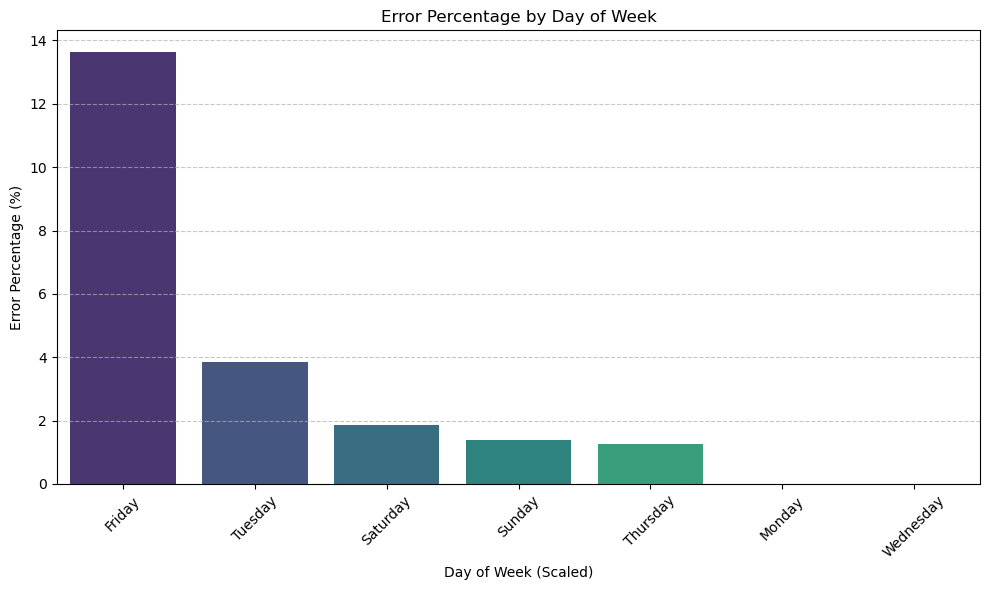

In [42]:
plt.figure(figsize=(10, 6))
sns.barplot(x=error_by_dayofweek.index, y=error_by_dayofweek['error_percentage'], palette='viridis', hue=error_by_dayofweek.index, legend=False)
plt.title('Error Percentage by Day of Week')
plt.xlabel('Day of Week (Scaled)')
plt.ylabel('Error Percentage (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()